In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import Series,DataFrame

import seaborn as sb
sb.set_style('whitegrid')



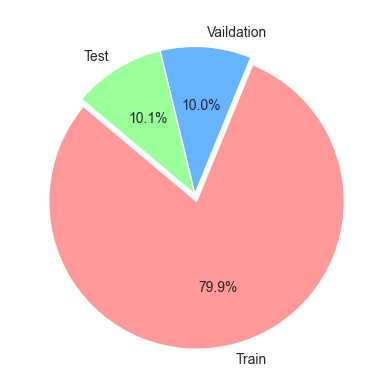

,Survived
0,0
1,0
2,0
3,0
4,0


In [23]:
from pathlib import Path


def get_output_path(filename):
    return Path().resolve().parent / 'output' / filename

# save dataset data

x_train = pd.read_csv(get_output_path('x_train.csv'))
y_train = pd.read_csv(get_output_path('y_train.csv'))
x_test = pd.read_csv(get_output_path('x_test.csv'))
y_test = pd.read_csv(get_output_path('y_test.csv'))
x_val = pd.read_csv(get_output_path('x_val.csv'))
y_val = pd.read_csv(get_output_path('y_val.csv'))

labels  = ['Train','Vaildation','Test']
sizes = [round(len(x_train)),round(len(x_val)),round(len(x_test))]
colors = ['#ff9999','#66b3ff','#99ff99']

plt.pie(sizes,labels=labels,autopct= '%1.1f%%',colors=colors,startangle=140,explode=(0.05,0,0))

plt.show()


y_train.head()


Survived Survived
0    444
1    268
Name: count, dtype: int64


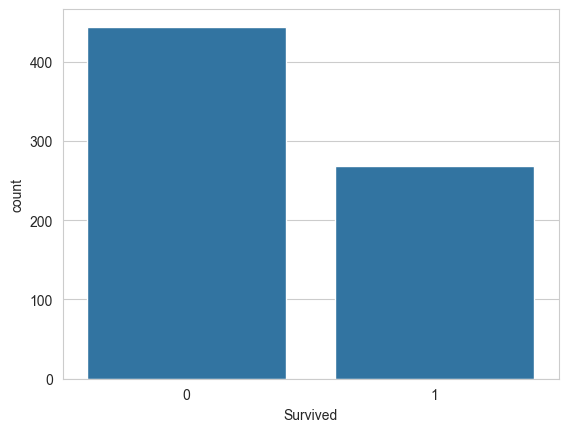

In [24]:
sb.countplot(x='Survived',data=y_train)

print('Survived',y_train['Survived'].value_counts())

In [25]:
# mini pipline

from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder



numeric_features = ['Age', 'Fare', 'FamilySize']
categoric_features = ['Sex', 'Pclass', 'Title', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessors = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, numeric_features),
        ('categoric', categoric_transformer, categoric_features),
    ]
) 

model = Pipeline(
    [
        ('preprocessor',preprocessors),
        ('classifier',LogisticRegression())
    ]
    
)


In [26]:
model.fit(x_train,y_train)


C:\Users\denis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categoric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
model.score(x_test,y_test)

0.7555555555555555

In [28]:
survival = model.predict(x_test)

print("ok", sum(survival!=0))
print("not ok",sum(survival==0))

ok 36
not ok 54


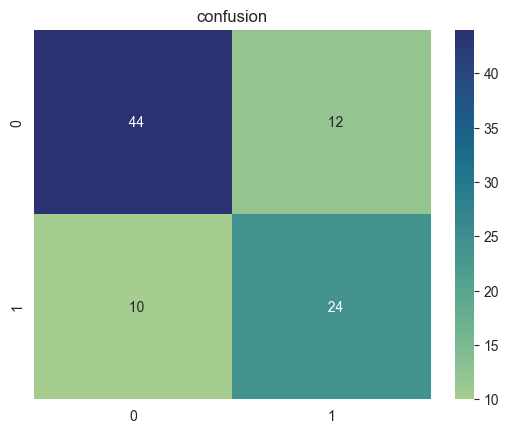

In [29]:
# confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,survival)
sb.heatmap(cm,annot=True,fmt='4.0f',cmap='crest')
plt.title('confusion',size=12)
plt.show()

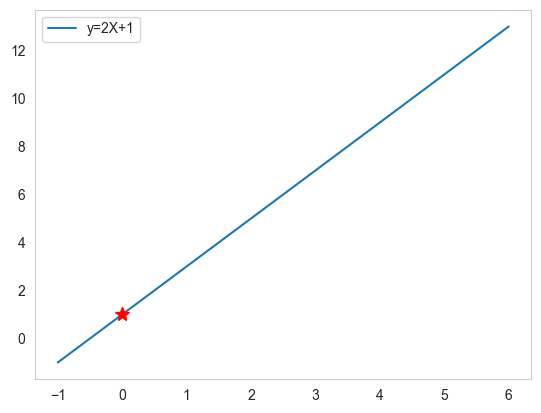

In [30]:
# simple linear  regression demo

X = np.arange(-1,7)
a = 2
b = 1
y = a*X+b

plt.plot(X,y,label=f'y={a}X+{b}')
plt.plot([0],[b], 'r*',markersize=10)
plt.grid()
plt.legend()

In [31]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X_blob, y_bloc = make_blobs(
    n_samples=50,
    n_features=3,
    centers=2,
    cluster_std=1.5,
    random_state=42,

) 

print(f"x shape {X_blob.shape}")
print(f"y shape {np.unique}")


print(X_blob)




x shape (50, 3)
y shape <function unique at 0x0000024CFFC88160>
[[ 2.36299388e+00 -5.70689288e+00 -8.73553566e+00]
 [ 1.68462824e+00 -6.42730618e+00 -6.93217725e+00]
 [ 1.62128898e+00 -9.00268330e+00 -7.51107758e+00]
 [-2.19590223e+00  6.07478094e+00  2.64759976e+00]
 [-3.41175754e+00  1.17927034e+01  4.61963300e+00]
 [ 2.57924597e+00 -4.05034834e+00 -6.61824287e+00]
 [ 1.21795620e+00 -9.20562234e+00 -6.77726513e+00]
 [-4.09576402e+00  1.02481035e+01  2.80861336e+00]
 [-1.29606910e-01 -5.99934155e+00 -3.59442615e+00]
 [ 3.15971760e+00 -8.24370837e+00 -4.77591813e+00]
 [ 1.48167646e+00 -7.46778942e+00 -9.07538202e+00]
 [-1.99377019e+00  6.36972590e+00  5.12600479e+00]
 [ 2.32155023e+00 -6.44001848e+00 -7.95163672e+00]
 [ 2.41735010e+00 -6.48804428e+00 -6.87243941e+00]
 [-2.37155646e+00  6.03293276e+00  4.31037100e+00]
 [-3.87123374e+00  6.89583058e+00  6.83835199e+00]
 [-7.51523569e-03 -6.09671484e+00 -6.43463258e+00]
 [ 3.19344551e+00 -8.72592367e+00 -6.53891969e+00]
 [ 2.46629635e+00 

before scaler [ 2.36299388 -5.70689288 -8.73553566]
after scaler [ 1.09592498 -0.82676804 -1.28659866]


C:\Users\denis\AppData\Local\Temp\ipykernel_8500\3020657975.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


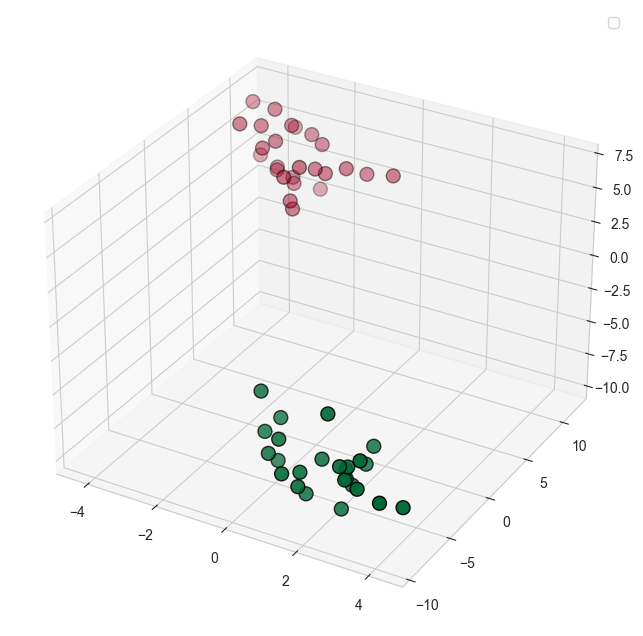

In [32]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()   
X_scaled = scaler.fit_transform(X_blob)


print(f"before scaler {X_blob[0]}")
print(f"after scaler {X_scaled[0]}")


fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_blob[:, 0], X_blob[:, 1],X_blob[:, 2], c=y_bloc, s=100, edgecolors='black', cmap='RdYlGn')


plt.grid(True)

plt.legend()

[[-0.76127322]
 [-1.41869179]
 [ 0.45129046]
 [-0.77111621]
 [ 0.23820651]
 [ 1.71873313]
 [ 0.41169756]
 [-0.82914259]
 [ 0.11046641]
 [ 0.69649121]
 [ 0.53760054]
 [-0.587295  ]
 [-3.1882251 ]
 [ 0.12046015]
 [ 1.16915177]
 [ 0.41580869]
 [-0.2402943 ]
 [ 0.93843451]
 [ 1.10014328]
 [ 0.10098614]
 [-1.21878863]
 [ 0.27863321]
 [ 0.79977834]
 [-0.54989369]
 [ 0.47683863]]
[0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1 0 1]


C:\Users\denis\AppData\Local\Temp\ipykernel_8500\2535099648.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


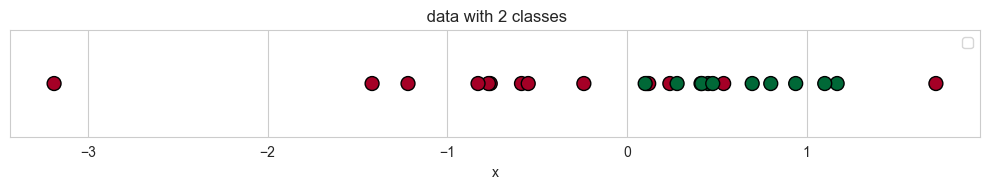

In [33]:
from sklearn.datasets import make_classification


X,y = make_classification(
    n_samples=25,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    random_state=11,
    n_clusters_per_class=1,
    class_sep=0.4
)


scaler = StandardScaler(

)
X = scaler.fit_transform(X)

print(X),
print(y)

plt.figure(figsize=(10,2))
plt.scatter(X,np.zeros_like(X),c=y,s=100,edgecolors='black',cmap='RdYlGn')
plt.xlabel('x')
plt.title(f' data with {len(np.unique(y))} classes')
plt.yticks([])
plt.tight_layout()
plt.legend()



In [34]:
from sklearn.linear_model import LogisticRegression 

model = LogisticRegression(random_state=42)
model.fit(X,y.ravel())

model.coef_, model.intercept_

(array([[1.34494091]]), array([-0.19801197]))

In [35]:
# in thist 


y_pred = model.predict(X)

y_proba = model.predict_proba(X)[:,1]

y_from_proba = (y_proba>=0.5).astype(int)
assert np.all(y_pred==y_from_proba) ,"not the same"

for i in range(5):
    print(f"true {y[i]}, pred {y_pred[i]}, proba {y_proba[i]}, from proba {y_from_proba[i]}")

true 0, pred 0, proba 0.2276058695763228, from proba 0
true 0, pred 0, proba 0.10850838346141464, from proba 0
true 1, pred 1, proba 0.6008353696911444, from proba 1
true 0, pred 0, proba 0.22528696209377816, from proba 0
true 0, pred 1, proba 0.5305523187359933, from proba 1


In [36]:

def sigmoid(x: np.ndarray) -> np.ndarray:

    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


test_inputs = np.array([-1000, -3, -1, 0, 1, 3, 1000])
print("z → sigmoid(z):")
for z in test_inputs:
    print(f"  sigmoid({z}) = {sigmoid(z):.2f}")

z → sigmoid(z):
  sigmoid(-1000) = 0.00
  sigmoid(-3) = 0.05
  sigmoid(-1) = 0.27
  sigmoid(0) = 0.50
  sigmoid(1) = 0.73
  sigmoid(3) = 0.95
  sigmoid(1000) = 1.00


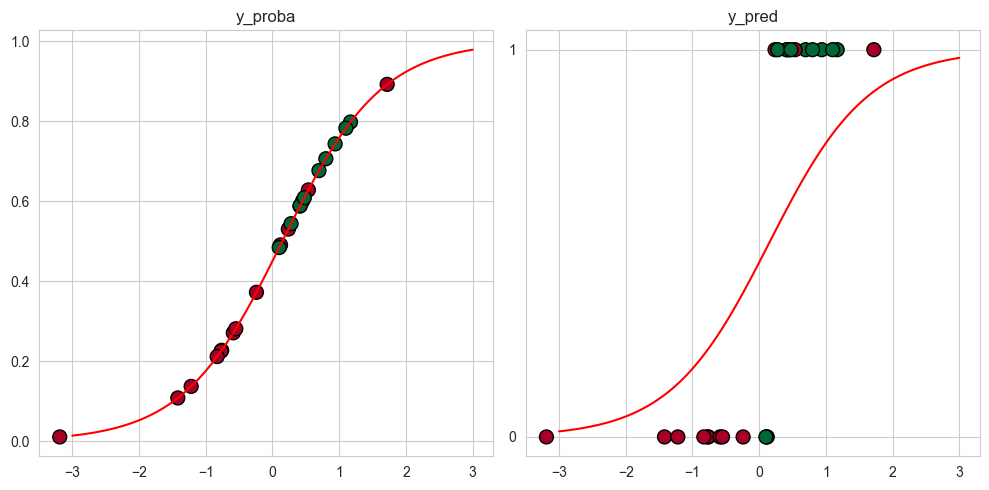

In [37]:
model_a = model.coef_[0]
model_b = model.intercept_[0]


fig,axes = plt.subplots(1,2,figsize=(10,5))


x_line = np.linspace(-3,3,num=100)
model_y_sk = model_a * x_line + model_b



axes[0].plot(x_line,sigmoid(model_y_sk),c='r')
axes[0].scatter(X,y_proba,c=y,s=100,edgecolors='black',cmap='RdYlGn')
axes[0].set_title('y_proba')


axes[1].plot(x_line,sigmoid(model_y_sk),c='r')
axes[1].scatter(X,y_pred,c=y,s=100,edgecolors='black',cmap='RdYlGn')
axes[1].set_yticks([0,1])
axes[1].set_title('y_pred')

plt.tight_layout()
plt.show()

# likelihood

In [38]:
import numpy as np

def simple_likelihood(y_true,y_proba):
    contribution = y_proba ** y_true + (1 - y_proba) ** (1 - y_true)

    return np.prod(contribution)

y_true  = np.array([0,0,1])
y_proba = np.array([0.1,0.2,0.7])

print(simple_likelihood(y_true,y_proba))

5.814


# Log-Loss

In [39]:
def Log_loss(y_true,y_proba):
    y_proba = np.clip(y_proba,1e-15,1-1e-15)

    log_count =- y_true * np.log(y_proba) - (1 - y_true) * np.log(1 - y_proba)

    return np.mean(log_count)






print(Log_loss(y_true,y_proba))



0.22839300363692283


C:\Users\denis\AppData\Local\Temp\ipykernel_8500\1092542485.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


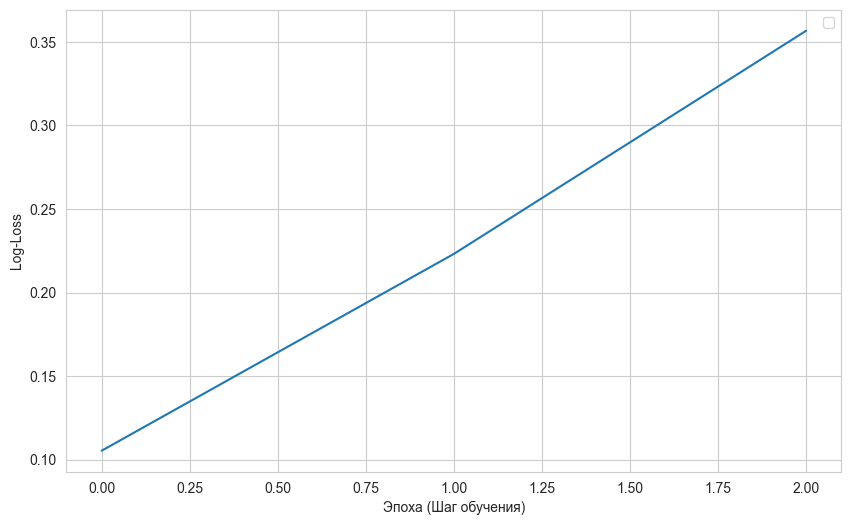

In [40]:
y_true  = np.array([0,0,1])
y_proba = np.array([0.1,0.2,0.7])

loss_history = []

for i in range (len(y_true)):
    current_loss = Log_loss(y_true[i],y_proba[i])
    loss_history.append(current_loss)



plt.figure(figsize=(10, 6))
plt.xlabel('Эпоха (Шаг обучения)')
plt.ylabel('Log-Loss')
plt.plot(loss_history)
plt.legend()

# Gradient descent

W_new = W_old - learning_rate * ∇Loss(W)

In [74]:
class LogisticRegressionFromScratch:
    """
        logistic regression from scratch, learning with gradient descent
    """

    def __init__(
            self,
            learning_rate: float = 0.01,
            n_iter: int = 250,
            eps: float = 1e-4,
            verbose: bool = True,
            log_every: int = 50
    ):
        
        self.learning_rate = learning_rate
        self.n_iterations = n_iter
        self.eps = eps
        self.verbose = verbose
        self.log_every = log_every


        self.W = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        x = np.clip(x, -500, 500) # overflow error guard
        return 1.0 / (1.0 + np.exp(-x)) # standart sigmoid
    

    @staticmethod
    def _logloss(y_true:np.ndarray,y_proba:np.ndarray):
        eps = 1e-15
        y_proba = np.clip(y_proba,eps,1-eps)
        return float(-np.mean(y_true * np.log(y_proba) + (1 - y_true) * np.log(1 - y_proba)))
        
    

    @staticmethod
    def _add_bias(X: np.ndarray) -> np.ndarray:
        return np.c_[np.ones(X.shape[0]), X]
    
    
    

    def _gradient(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        y_proba = self._sigmoid(X @ self.W) 
        return (X.T @ (y_proba - y)) / X.shape[0]  # vector of gradients
    

    def fit(self, X: np.ndarray, y: np.ndarray,threshold: float = 0.5):
        X_with_bias = self._add_bias(X)

        np.random.seed(42)
        self.W = np.random.randn(X_with_bias.shape[1]) * 0.01

        for i in range(self.n_iterations):
            prev_W = self.W.copy()


            # gradient descent    
            self.W = self.W - self.learning_rate * self._gradient(X_with_bias, y) # W_new = W_old - learning_rate * ∇Loss(W)


            # save 

            y_proba = self._sigmoid(X_with_bias @ self.W)
            loss =  self._logloss(y, y_proba)
            self.loss_history.append(loss)


             # extremum point
                 
            if np.linalg.norm(prev_W - self.W) <= self.eps:
                if(self.verbose):
                    print(f'converged at {i} iterations')
                break
            # log
            
            if(self.verbose and i % self.log_every == 0):
                accuracy = np.mean((y_proba>=threshold).astype(int)==y)
                print(f"{i} iterations has {accuracy} accuracy and {loss} loss")



        return self
    

    def predict_proba(self,X: np.ndarray):
        X_with_bias = self._add_bias(X)
        return self._sigmoid(X_with_bias @ self.W)
    
    def predict(self,X: np.ndarray,threshold: float = 0.5)-> np.ndarray:
        return (self.predict_proba(X)>=threshold).astype(int)
    

    def score(self,X: np.ndarray,y: np.ndarray)->float:
        return float(np.mean(self.predict(X)==y))
    




In [66]:
# used

from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler



X_make, y_make = make_classification(
    n_samples = 25,
    n_features = 1,
    n_informative = 1,
    random_state = 42,
    n_clusters_per_class = 1,
    class_sep = 0.4,
    n_redundant = 0
)




# pipeline our model with standart scaler

X_make_with_bias = LogisticRegressionFromScratch._add_bias(X_make)

X_make = StandardScaler().fit_transform(X_make_with_bias)


my_model = LogisticRegressionFromScratch(
    log_every=50

)


my_model.fit(X_make_with_bias,y_make)


print(my_model.score(X_make_with_bias,y_make))





0 iterations has 0.72 accuracy and0.6905336516271564 loss
50 iterations has 0.96 accuracy and0.6517678318359218 loss
100 iterations has 0.96 accuracy and0.6177472476038116 loss
150 iterations has 0.96 accuracy and0.5878079651728957 loss
200 iterations has 0.96 accuracy and0.5613767385401717 loss
0.96


# visualize loss in 3d 

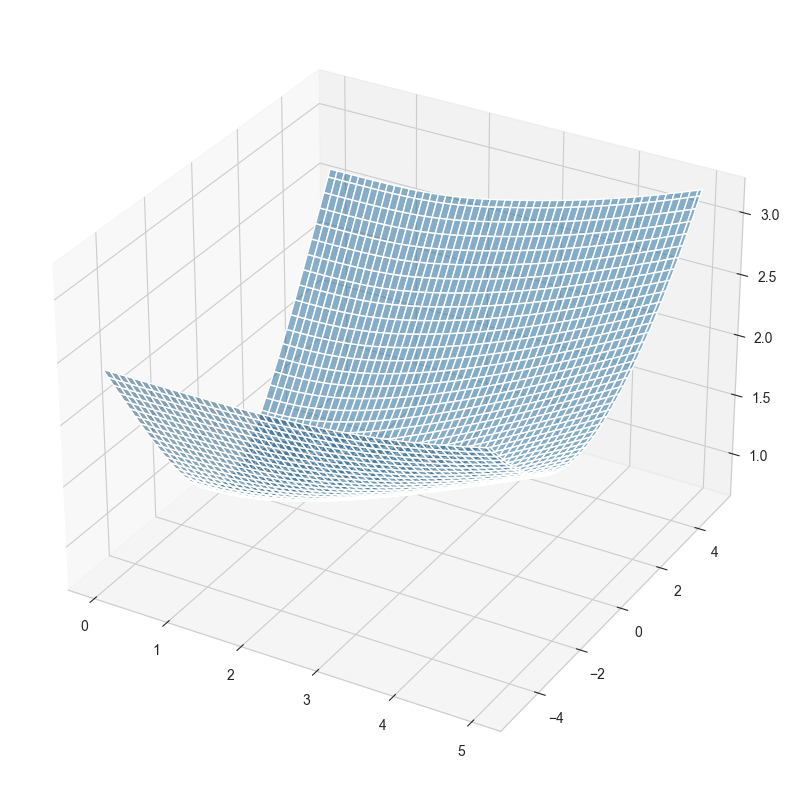

In [75]:
from mpl_toolkits.mplot3d.axes3d import Axes3D

def logloss(w1,w0):
    y_pred = sigmoid(w1 * X + w0)
    return LogisticRegressionFromScratch._logloss(y, y_pred)


coefs_a = np.linspace(0,5,num=100)
coefs_b = np.linspace(-5,5,num=100)
w1, w0 = np.meshgrid(coefs_a,coefs_b)

coefs_a = np.linspace(0, 5, num=100)
coefs_b = np.linspace(-5, 5, num=100)
w1, w0 = np.meshgrid(coefs_a, coefs_b)

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
zs = np.array([logloss(i, j) for i, j in zip(np.ravel(w1), np.ravel(w0))])
Z = zs.reshape(w1.shape)
ax.plot_surface(w1, w0, Z, alpha=.5)


The surface is skewed: The bowl is slightly stretched and elongated (like a trough). This asymmetry happens because we appended a column of ones to $X$ to handle the bias ($w_0$). Since this bias column is locked at 1 while other features have different scales, the gradient updates for the bias crawl much slower, distorting the loss landscape.